In [13]:
#Packages to Import

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

FileNmBase= "Data/Advection_Diffusion_Toy/"

In [14]:
#Numerical Set up for AD Toy Model
#AD Toy Model

def MkAD_A_Mat(ModDim, curApar):
    """
    Generates an antisymmetric matric with the given Model Parameters
    """
    A = np.zeros([ModDim,ModDim])
    A[np.triu_indices(ModDim, k=1)] = curApar 
    #triu_indices returns the indices of all the above diagonal indicies
    return A - A.T

def getThA(ModDim, Apar, g, kappa):
    """
    Solves (A + kI) th = g  for theta given the specified model parameters determining A
    """
    A_p_kI = MkAD_A_Mat(ModDim, Apar)+ kappa*np.identity(ModDim)
    return np.linalg.solve(A_p_kI,g)

def mkDiagCov(vrs):
    return np.diag(vrs)


#Code to generate a random orthogonal matrix (uniform from O(n)) using the QR factorization of a Guassian matrix.
def rndm_orth_matrix(n):

    #Generate a random n x n matrix with i.i.d. normal entries
    A = np.random.randn(n, n)
    
    #Perform the QR factorization
    Q, R = np.linalg.qr(A)    
    
    return Q
    

In [42]:
ModDm = 4
NumParms = int(ModDm*(ModDm -1)/2)


g = np.ones(ModDm)
kaplst = {.01, .03, .07, .09, .23, .4,.6,.5}

print("Model dim: " + str(ModDm))

aveLen = 5000

for kap in kaplst:
    print("current kappa: " + str(kap))
    cent0 = np.zeros(NumParms)
    print("Center: " + str(cent0))
    th_0 = getThA(ModDm,cent0 , g, kap)
    print("Example: " + str(norm(th_0  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
    difflst0 = []
    for k in range(1,aveLen):
        difflst0.append(norm(th_0  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

    data0 = np.array(difflst0, dtype=float)
    print("MEAN: " + str(data0.mean()))
    print("VAR: " + str(data0.var(ddof=0)))
    #print("\n")

    #print("current kappa: " + str(kap))
    cent1 = np.ones(NumParms)
    print("Center: " + str(cent1))
    th_1 = getThA(ModDm, cent1, g, kap)
    print("Example: " +str(norm(th_1  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
    difflst1 = []
    for k in range(1,aveLen):
        difflst1.append(norm(th_1  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

    data1 = np.array(difflst1, dtype=float)
    print("MEAN: " + str(data1.mean()))
    print("VAR: " + str(data1.var(ddof=0)))
    #print("\n")

    #print("current kappa: " + str(kap))
    centr= np.random.normal(0, 1, NumParms)
    print("Center: " + str(centr))
    th_r = getThA(ModDm, centr, g, kap)
    print("Example: " + str(norm(th_r  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap))))
    difflstr = []
    for k in range(1,aveLen):
        difflstr.append(norm(th_r  - getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)))

    datar = np.array(difflstr, dtype=float)
    print("MEAN: " + str(datar.mean()))
    print("VAR: "  + str(datar.var(ddof=0)))
    print("\n ")


Model dim: 4
current kappa: 0.03
Center: [0. 0. 0. 0. 0. 0.]
Example: 66.59421300180463
MEAN: 65.58861976313185
VAR: 15.51614596152244
Center: [1. 1. 1. 1. 1. 1.]
Example: 4.148463651876516
MEAN: 6.674972945322138
VAR: 74.58928038106536
Center: [ 0.01830514 -0.6078841   0.26415512 -0.07312475  0.93653793  0.9932954 ]
Example: 5.143685382240583
MEAN: 6.608837321075898
VAR: 83.26025319738959

 
current kappa: 0.4
Center: [0. 0. 0. 0. 0. 0.]
Example: 1.1054794084497106
MEAN: 4.218632980918695
VAR: 0.5831417659620158
Center: [1. 1. 1. 1. 1. 1.]
Example: 0.5037223370441977
MEAN: 2.582749187580076
VAR: 1.0222257460781636
Center: [ 1.14073675  0.0998281  -0.27057253 -1.07922228  0.16067241 -0.74444493]
Example: 4.222781938709011
MEAN: 3.149440487584778
VAR: 0.855929609269399

 
current kappa: 0.09
Center: [0. 0. 0. 0. 0. 0.]
Example: 22.16302031010345
MEAN: 21.29270166568172
VAR: 4.111377382108255
Center: [1. 1. 1. 1. 1. 1.]
Example: 3.6469567984760207
MEAN: 5.00648196184885
VAR: 15.760659598

In [47]:
#Example 5:  Difficult Data

#Specifying Problem Parameters


#Model Dimension and Parameter Size

ModDm = 4 #Size of the matrix
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}
#g0 = 1
#g1 = 1
#g = np.transpose(np.array([g0,g1,1,1,1,1]))
g = np.ones(ModDm)
#g = np.random.normal(0, 1, ModDm)

# Coefficent of the `regularization/diffusion term'
kap = .5

#Specification `observed data' y0, y1
#Note, when A = 0, \th(A) =  kap^{-1} g.  So we specify y as y = \th(A) + \epsilon
#eps0 = .3
#eps1 = .1
#y0 = kap**(-1)*g0 + eps0
#y1 = kap**(-1)*g1 + eps1

#y = [y0,y1]
#yData = np.array([y0,y1,0,0,0,0])


nyData = ModDm
#yData = np.random.normal(0, 1, ModDm)
#yData = getThA(ModDm, np.random.normal(0, 1, NumParms), g, kap)
yData = getThA(ModDm, np.zeros(NumParms), g, kap)

# `observation noise coefficent'

sig = .5

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(1))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)


#Poty = lambda a : (2*sig**2)**(-1)*(np.sum(y - getThA(ModDm, a, g, kap)[0:1])**2)
#Poty = lambda a : (2*sig**2)**(-1)*(np.sum(yData[0:nyData] - getThA(ModDm, a, g, kap)[0:nyData])**2)
Poty = lambda a : (2*sig**2)**(-1)*(norm(yData[0:nyData] - getThA(ModDm, a, g, kap)[0:nyData]))**2


#CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]
#Q = rndm_orth_matrix(NumParms)
#Cov = Q.T@ mkDiagCov(CovDiag)@ Q

Cov = np.array([[ 3.09615255, -0.42256446, -0.01699562, 1.52032843, 0.196684, 0.91198176],
 [-0.42256446,  0.47653539,  0.13517459, -0.15567356, -0.12246178,  0.03620587],
 [-0.01699562,  0.13517459,  0.90420916,  0.35872565,  0.0865228,   0.42293649],
 [ 1.52032843, -0.15567356,  0.35872565,  2.1249358,   0.03393446,  1.34534855],
 [ 0.196684,   -0.12246178,  0.0865228,   0.03393446,  0.90437014, -0.111162  ],
 [ 0.91198176,  0.03620587,  0.42293649,  1.34534855, -0.111162,    1.63623487]])


expId = 4
probDataFile = FileNmBase + "Problem_Data_Ex_ID_5_" + str(expId) + ".txt"

with open(probDataFile, 'a') as file:
    file.write("model dim: " + str(ModDm) + "\n")
    file.write("gvec: " + str(g) + "\n")
    file.write("kap: " + str(kap) + "\n")
    file.write("y: " + str(yData) + "\n")
    file.write("sig: " + str(sig)+ "\n")
    file.write("Prior Cov: \n \t" + str(Cov))


In [48]:


#Generate Data Using MpCN

#NumRuns =  1000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  10 #of total runs
NumSamps = 1000 #samples per run



rho = .1
pSmp = 100

print("  ")
print("pCN Run")

paraStr = "Exp_Nm_5_" + str(expId)
histFileNm = FileNmBase + "MpCN_HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "MpCN_DATA" + paraStr + ".csv"

print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        #cursamps = locMpCNMTM(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1,True)
        cursamps = MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)
        q0 = cursamps[NumSamps+1]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))
        

  
pCN Run
Total samples generated: 10000
rho Value: 0.1
p Value: 100
  


  0%|          | 0/10 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0


Number of MpCN Samples Now Available: 10019


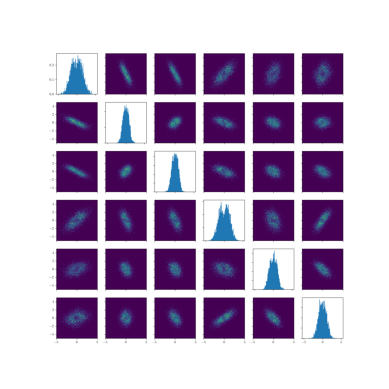

In [49]:
#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()